# Zomato Restaurant Analysis

## Objective
#Analyze restaurant data to discover trends in ratings, cuisines, costs, cities, and customer preferences using Python and Pandas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
df = pd.read_csv("zomato.csv")

# Dataset Overview

Before performing any analysis, we need to understand the structure of the dataset, identify data types, check for missing values, and detect duplicate records.

In [30]:
print("shape of dataset : ", df.shape)

shape of dataset :  (123657, 26)


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123657 entries, 0 to 123656
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Restaurant_Name        123657 non-null  object 
 1   Dining_Rating          123657 non-null  float64
 2   Delivery_Rating        123657 non-null  float64
 3   Dining_Votes           123657 non-null  int64  
 4   Delivery_Votes         123657 non-null  int64  
 5   Cuisine                123657 non-null  object 
 6   Place_Name             123657 non-null  object 
 7   City                   123657 non-null  object 
 8   Item_Name              123657 non-null  object 
 9   Best_Seller            123657 non-null  object 
 10  Votes                  123657 non-null  int64  
 11  Prices                 123657 non-null  float64
 12  Average_Rating         123657 non-null  float64
 13  Total_Votes            123657 non-null  int64  
 14  Price_per_Vote         123657 non-nu

In [32]:
df.describe(include="all")

,Restaurant_Name,Dining_Rating,Delivery_Rating,Dining_Votes,Delivery_Votes,Cuisine,Place_Name,City,Item_Name,Best_Seller,...,Is_Bestseller,Restaurant_Popularity,Avg_Rating_Restaurant,Avg_Price_Restaurant,Avg_Rating_Cuisine,Avg_Price_Cuisine,Avg_Rating_City,Avg_Price_City,Is_Highly_Rated,Is_Expensive
count,123657,123657.000000,123657.000000,123657.000000,123657.000000,123657,123657,123657,123657,123657,...,123657.0,123657.000000,123657.000000,123657.000000,123657.000000,123657.000000,123657.000000,123657.000000,123657.000000,123657.000000
unique,826,NaN,NaN,NaN,NaN,48,324,17,55693,14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,McDonald's,NaN,NaN,NaN,NaN,Beverages,C Scheme,Hyderabad,Veg Fried Rice,NONE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2059,NaN,NaN,NaN,NaN,39441,3775,15613,322,95715,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,3.822264,3.963184,152.729858,115.763725,NaN,NaN,NaN,NaN,NaN,...,1.0,304.008143,3.892724,241.378399,3.892724,241.378399,3.892724,241.378399,0.373970,0.243464
std,NaN,0.351407,0.244624,232.214061,243.970828,NaN,NaN,NaN,NaN,NaN,...,0.0,346.309371,0.229933,94.690020,0.074554,30.359509,0.025634,29.121965,0.483858,0.429174
min,NaN,2.500000,2.500000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,...,1.0,4.000000,3.000000,35.833333,3.406122,61.428571,3.600000,194.591645,0.000000,0.000000
25%,NaN,3.700000,3.800000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,...,1.0,125.000000,3.750000,178.460526,3.873352,212.572315,3.880503,223.676576,0.000000,0.000000
50%,NaN,3.822264,4.000000,30.000000,0.000000,NaN,NaN,NaN,NaN,NaN,...,1.0,195.000000,3.911132,230.959514,3.913401,254.565364,3.889413,235.550603,0.000000,0.000000
75%,NaN,4.000000,4.100000,217.000000,23.000000,NaN,NaN,NaN,NaN,NaN,...,1.0,318.000000,4.050000,285.146825,3.928624,255.954894,3.907014,245.130482,1.000000,0.000000


# Data Cleaning

Data cleaning ensures that the dataset is accurate, consistent, and suitable for analysis.

### Steps Performed

- Checked for missing values.
- Checked for duplicate records.
- Removed duplicate rows.
- Verified the cleaned dataset.

In [33]:
# Missing values
df.isnull().sum()

Restaurant_Name          0
Dining_Rating            0
Delivery_Rating          0
Dining_Votes             0
Delivery_Votes           0
Cuisine                  0
Place_Name               0
City                     0
Item_Name                0
Best_Seller              0
Votes                    0
Prices                   0
Average_Rating           0
Total_Votes              0
Price_per_Vote           0
Log_Price                0
Is_Bestseller            0
Restaurant_Popularity    0
Avg_Rating_Restaurant    0
Avg_Price_Restaurant     0
Avg_Rating_Cuisine       0
Avg_Price_Cuisine        0
Avg_Rating_City          0
Avg_Price_City           0
Is_Highly_Rated          0
Is_Expensive             0
dtype: int64

In [35]:
# Duplicate rows
df.duplicated().sum()

np.int64(22127)

In [36]:
# Remove duplicate rows
df = df.drop_duplicates()

# Verify
print(df.shape)
print(df.duplicated().sum())

(101530, 26)
0


# Exploratory Data Analysis (EDA)

The objective of EDA is to analyze restaurant performance, customer behavior, pricing trends, cuisine preferences, and city-wise distribution to generate actionable business insights for Zomato.

## Business Question 1

### Which city has the highest number of restaurants?

Understanding the distribution of restaurants across cities helps identify major markets and potential expansion opportunities.

In [47]:
# Count restaurants in each city
city_restaurants = df["City"].value_counts()

top10 = city_restaurants.head(10)

top10

City
Hyderabad    13100
Mumbai       11640
Chennai      11147
Jaipur       11009
Bangalore     9450
Ahmedabad     8519
Kolkata       6955
Pune          6655
Kochi         6281
Raipur        6272
Name: count, dtype: int64

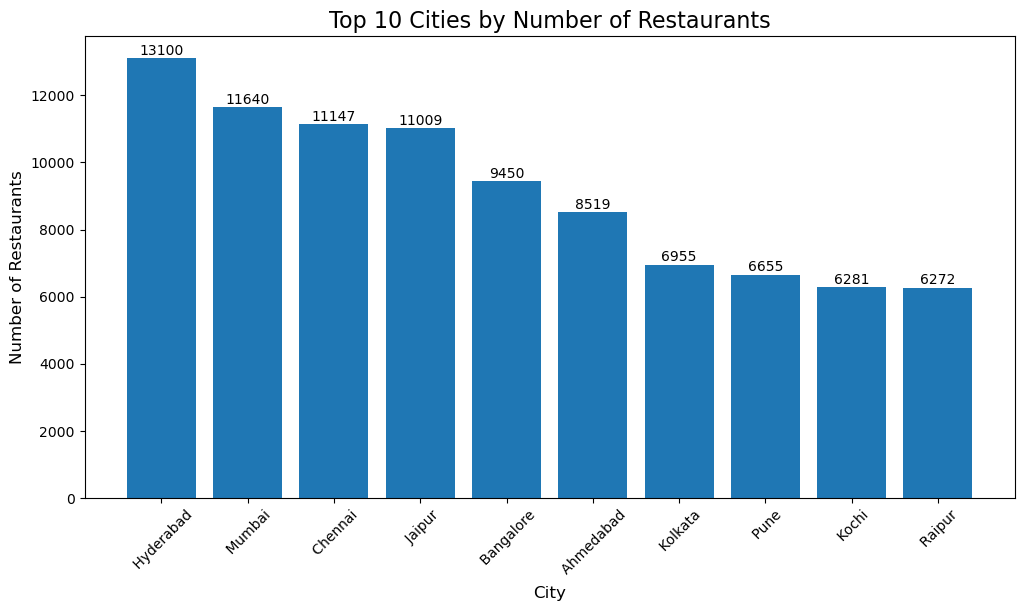

In [48]:
plt.figure(figsize=(12,6))

plt.bar(top10.index, top10.values)

plt.title("Top 10 Cities by Number of Restaurants", fontsize=16)
plt.xlabel("City", fontsize=12)
plt.ylabel("Number of Restaurants", fontsize=12)

plt.xticks(rotation=45)

# Add values on top of each bar
for i, value in enumerate(top10.values):
    plt.text(i, value + 100, str(value), ha='center', fontsize=10)

plt.show()

## Insight

- Hyderabad has the highest number of restaurants in the dataset.
- Mumbai, Chennai, and Jaipur also have a strong restaurant presence.
- Kochi and Raipur have comparatively fewer restaurants than the top cities.
- The distribution suggests that restaurant density varies significantly across cities.

## Business Recommendation

- Continue strengthening partnerships in Hyderabad.
- Identify high-demand cities with fewer restaurants and expand restaurant onboarding.

# Business Question 2

## Which city has the highest average restaurant rating?

### Objective

The objective of this analysis is to identify the cities with the highest average restaurant ratings. This helps us understand where customers are most satisfied with their dining experience.

### Why is this analysis important?

- It identifies cities with the best-performing restaurants.
- It helps Zomato understand customer satisfaction across different cities.
- It provides insights that can help improve restaurant quality in lower-rated cities.

In [51]:

city_rating = df.groupby("City")["Average_Rating"].mean().sort_values(ascending=False)

top10_rating = city_rating.head(10)

top10_rating

City
Malleshwaram    4.000000
New Delhi       3.944014
Hyderabad       3.939896
Ulsoor          3.911132
Lucknow         3.907232
Goa             3.898856
Kolkata         3.898313
Chennai         3.893292
Pune            3.887593
Mumbai          3.886450
Name: Average_Rating, dtype: float64

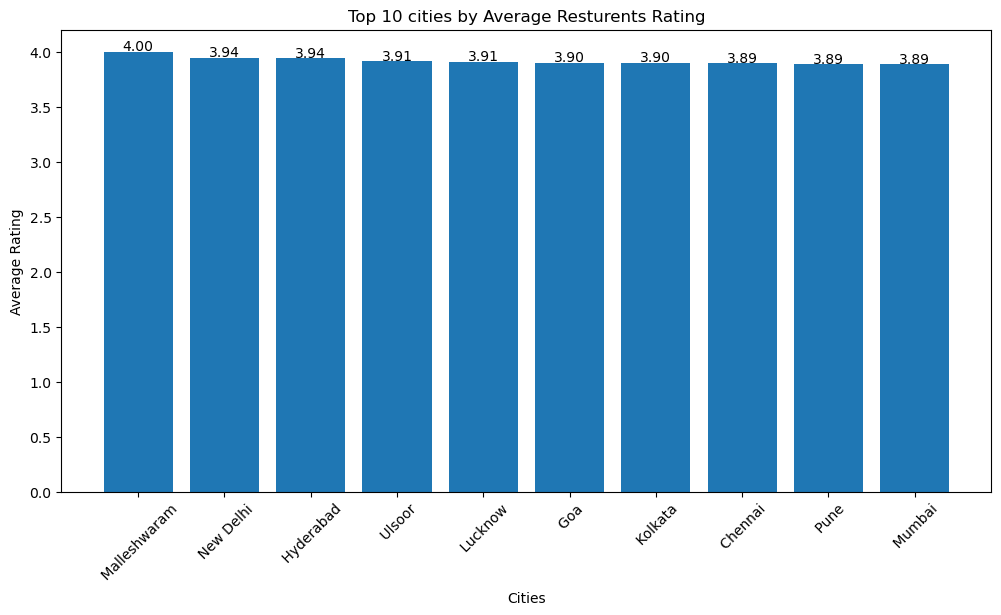

In [52]:
plt.figure(figsize=(12,6))

plt.bar(top10_rating.index, top10_rating.values)

plt.title("Top 10 cities by Average Resturents Rating")
plt.xlabel("Cities")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)

for i, value in enumerate(top10_rating.values):
        plt.text(i, value + 0.01, f"{value:.2f}", ha="center")
plt.show()

## Insight

- The chart shows the average restaurant rating for the top 10 cities.
- Cities with higher average ratings indicate better customer satisfaction and restaurant quality.
- These cities can serve as benchmarks for improving restaurant performance in other locations.

## Business Recommendation

- Promote highly rated restaurants through marketing campaigns.
- Study the factors contributing to high ratings in these cities.
- Encourage restaurants in lower-rated cities to adopt best practices to improve customer satisfaction.

# Business Question 3

## Which cuisine has the highest number of restaurants?

### Objective

The objective of this analysis is to identify the cuisines with the highest number of restaurants on the Zomato platform.

### Why is this analysis important?

- It helps identify the most common cuisines.
- It helps Zomato understand restaurant distribution across different cuisines.
- It supports business decisions related to restaurant onboarding and promotional campaigns.

In [56]:
# Count the number of resturent for each cuisine
cuisine_count = df["Cuisine"].value_counts()

top10_cuisine = cuisine_count.head(10)

top10_cuisine


Cuisine
Beverages       32818
Pizza           12383
Desserts         9285
Fast Food        9268
Chinese          5066
Sichuan          4812
Biryani          3462
Shake            2784
North Indian     2436
Street Food      2371
Name: count, dtype: int64

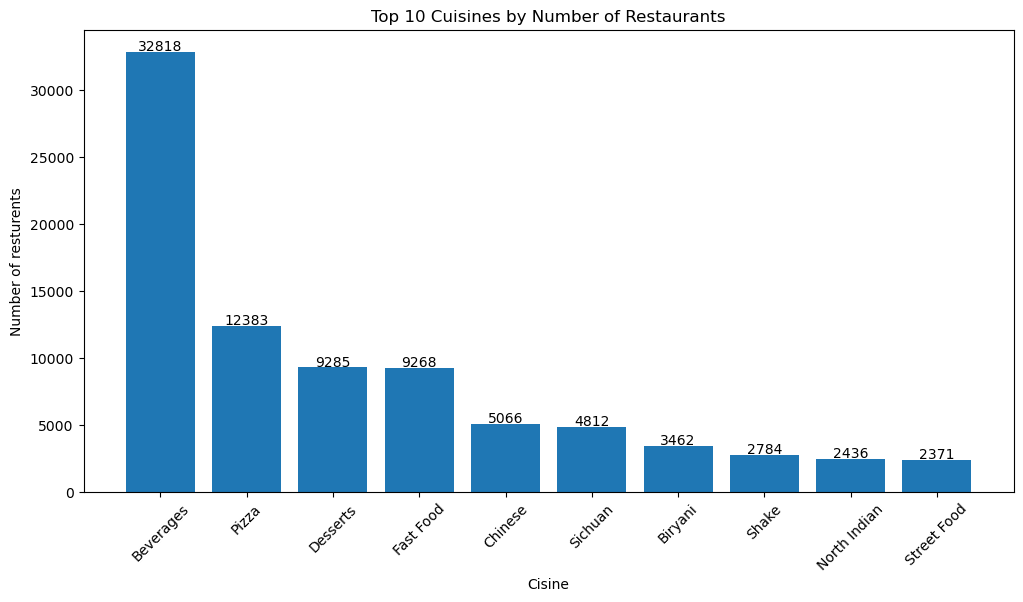

In [57]:
plt.figure(figsize=(12,6))

plt.bar(top10_cuisine.index, top10_cuisine.values)

plt.title("Top 10 Cuisines by Number of Restaurants")
plt.xlabel("Cisine")
plt.ylabel("Number of resturents")

plt.xticks(rotation=45)

for i, value in enumerate(top10_cuisine.values):
        plt.text(i, value + 100, str(value), ha="center")
plt.show()

## Insight

- The chart shows the top 10 cuisines with the highest number of restaurants.
- The most common cuisine has the largest restaurant presence on the platform.
- This indicates higher availability and potentially stronger customer demand for that cuisine.

## Business Recommendation

- Continue strengthening partnerships in high-demand cuisines.
- Increase promotional campaigns for popular cuisines.
- Explore opportunities to onboard more restaurants in less represented cuisines where demand may be growing.

# Business Question 4

## Which cuisine has the highest average restaurant rating?

### Objective

The objective of this analysis is to identify the cuisines that receive the highest average customer ratings.

### Why is this analysis important?

- It helps identify the best-performing cuisines.
- It provides insights into customer preferences.
- It helps restaurants and Zomato understand which cuisines consistently deliver better customer satisfaction.

In [60]:
#Calculate average rating for each cuisine
cuisine_rating = (
    df.groupby("Cuisine")["Average_Rating"].mean().sort_values(ascending=False)
)


top10_cuisine_rating = cuisine_rating.head(10)

top10_cuisine_rating
    

Cuisine
Awadhi          4.250000
Andhra          4.250000
Tea             4.111132
Turkish         4.100000
Bakery          4.070581
Mexican         4.068591
Seafood         4.031735
Healthy Food    4.011132
Salad           4.005671
Tibetan         4.000000
Name: Average_Rating, dtype: float64

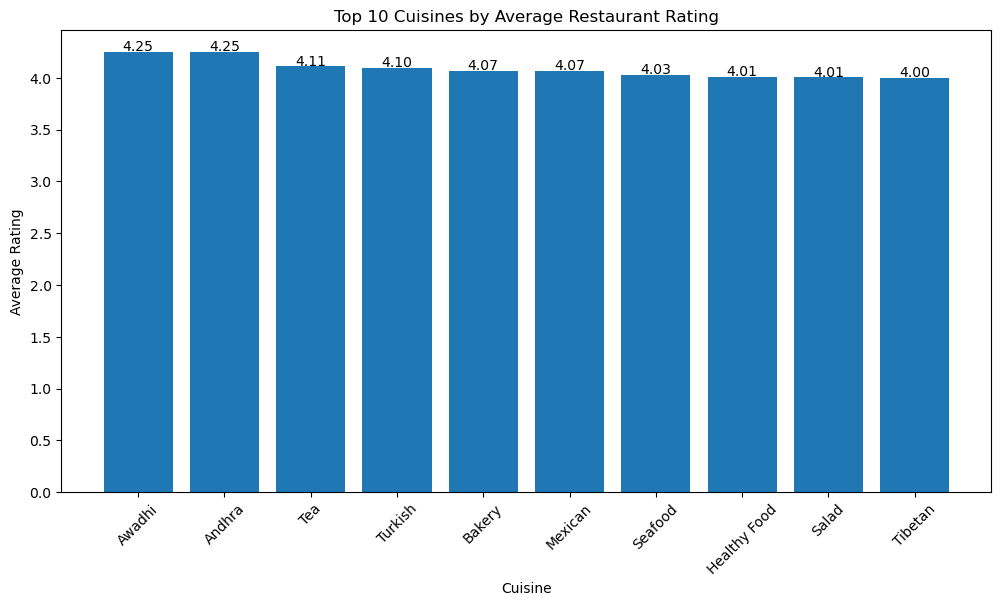

In [61]:
plt.figure(figsize=(12,6))

plt.bar(top10_cuisine_rating.index, top10_cuisine_rating.values)

plt.title("Top 10 Cuisines by Average Restaurant Rating")
plt.xlabel("Cuisine")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)

for i, value in enumerate(top10_cuisine_rating.values):
    plt.text(i, value + 0.01, f"{value:.2f}", ha='center')

plt.show()

## Insight

- The chart highlights the cuisines with the highest average restaurant ratings.
- These cuisines consistently receive positive customer feedback.
- High ratings indicate better food quality, service, or overall dining experience.

## Business Recommendation

- Promote highly rated cuisines through marketing campaigns.
- Encourage restaurants serving these cuisines to expand into more cities.
- Analyze the success factors behind these cuisines and apply similar strategies to lower-rated cuisine categories.

# Business Question 5

## Which restaurants have the highest average restaurant ratings?

### Objective

The objective of this analysis is to identify the top-rated restaurants based on their average customer ratings.

### Why is this analysis important?

- It helps identify the best-performing restaurants.
- It highlights restaurants that consistently provide high customer satisfaction.
- It helps Zomato promote top-rated restaurants to attract more customers.

In [62]:
restaurant_rating = (
    df.groupby("Restaurant_Name")["Average_Rating"]
      .mean()
      .sort_values(ascending=False)
)

top10_restaurant_rating = restaurant_rating.head(10)

top10_restaurant_rating

Restaurant_Name
Chaitanya            4.450000
Kings Kulfi          4.450000
Truffles             4.450000
Exotica              4.450000
Al Taza              4.400000
Mitra Cafe           4.400000
Boojee Cafe          4.400000
Thali and More       4.400000
Toscano              4.400000
Natural Ice Cream    4.398896
Name: Average_Rating, dtype: float64

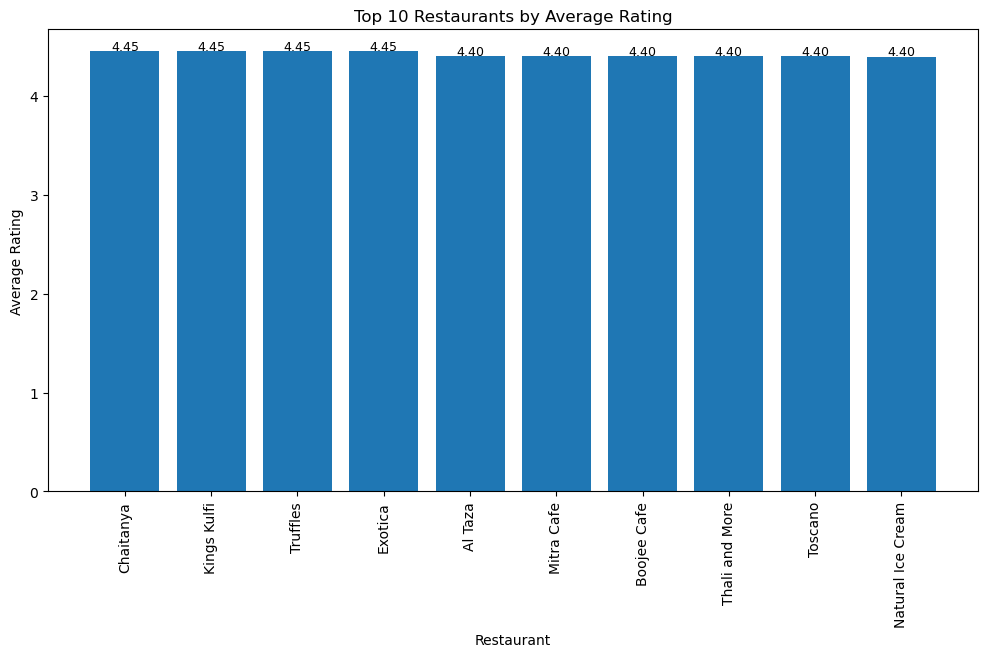

In [63]:
plt.figure(figsize=(12,6))

plt.bar(top10_restaurant_rating.index, top10_restaurant_rating.values)

plt.title("Top 10 Restaurants by Average Rating")
plt.xlabel("Restaurant")
plt.ylabel("Average Rating")

plt.xticks(rotation=90)

for i, value in enumerate(top10_restaurant_rating.values):
    plt.text(i, value + 0.01, f"{value:.2f}", ha="center", fontsize=9)

plt.show()

## Insight

- The chart identifies the restaurants with the highest average customer ratings.
- These restaurants consistently provide an excellent customer experience.
- High ratings indicate strong food quality, service, and customer satisfaction.

## Business Recommendation

- Promote top-rated restaurants through the Zomato app.
- Highlight these restaurants in recommendation sections.
- Encourage other restaurants to adopt best practices from these top performers.

# Business Question 6

## Which restaurants are the most popular?

### Objective

The objective of this analysis is to identify the restaurants with the highest popularity score.

### Why is this analysis important?

- It helps identify restaurants that attract more customers.
- It supports promotional campaigns for high-performing restaurants.
- It provides insights into customer preferences and restaurant performance.

In [64]:
restaurant_popularity = (
    df.groupby("Restaurant_Name")["Restaurant_Popularity"]
      .mean()
      .sort_values(ascending=False)
)

top10_popular = restaurant_popularity.head(10)

top10_popular

Restaurant_Name
McDonald's         2059.0
Domino's Pizza     1435.0
Burger King        1352.0
FreshMenu          1097.0
Pizza Hut          1077.0
Kanha               934.0
La Pino'z Pizza     868.0
Subway              823.0
KFC                 751.0
The Momoz Hub       700.0
Name: Restaurant_Popularity, dtype: float64

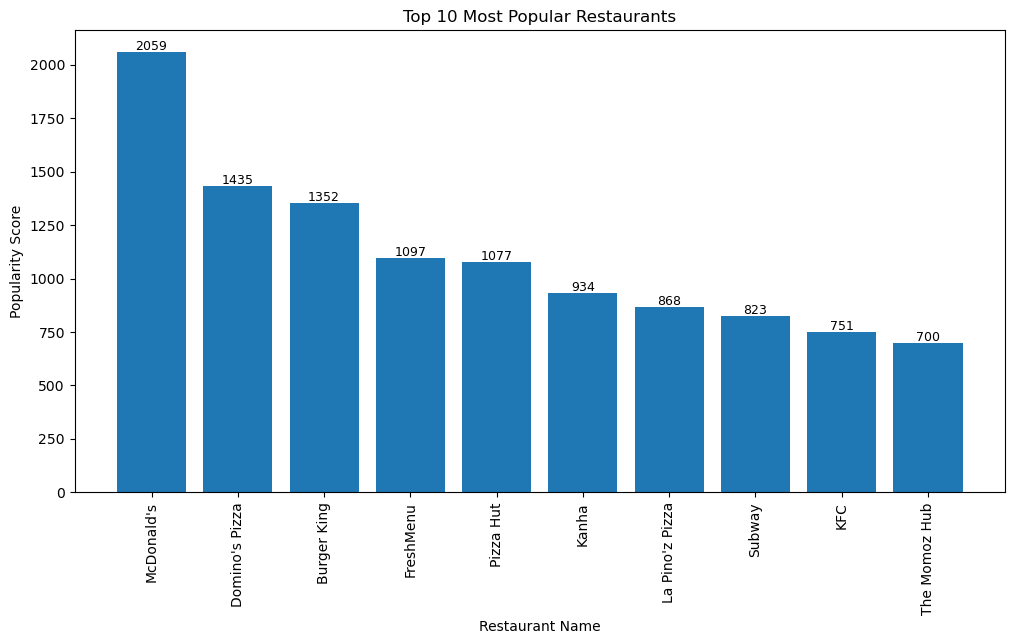

In [65]:
plt.figure(figsize=(12,6))

plt.bar(top10_popular.index, top10_popular.values)

plt.title("Top 10 Most Popular Restaurants")
plt.xlabel("Restaurant Name")
plt.ylabel("Popularity Score")

plt.xticks(rotation=90)

for i, value in enumerate(top10_popular.values):
    plt.text(i, value + 10, f"{value:.0f}", ha="center", fontsize=9)

plt.show()

## Insight

- The chart identifies the restaurants with the highest popularity scores.
- These restaurants attract a larger number of customers compared to others.
- High popularity may result from strong brand recognition, food quality, pricing, or customer experience.

## Business Recommendation

- Promote highly popular restaurants on the homepage.
- Partner with these restaurants for exclusive offers.
- Analyze the factors behind their popularity and apply similar strategies to improve the performance of other restaurants.

# Business Question 7

## Which restaurants have received the highest customer votes?

### Objective

The objective is to identify restaurants with the highest customer engagement based on total votes.

### Why is this analysis important?

- Restaurants with more votes have higher customer engagement.
- High vote counts often indicate strong brand recognition and customer trust.

In [66]:
restaurant_votes = (
    df.groupby("Restaurant_Name")["Total_Votes"]
      .mean()
      .sort_values(ascending=False)
)

top10_votes = restaurant_votes.head(10)

top10_votes

Restaurant_Name
Zaffran Mataam Alarabi               1393.0
Jimis Burger                         1388.0
Annamaya                             1139.0
Lina's Brickoven Newyork Pizzeria    1040.0
Z K Fry Centre                       1035.0
Goli Vadapav No.1                    1031.0
PFZ                                  1005.0
Govind Dosa                           997.0
Bucket Biryani                        996.0
A Balaji Santosh Dhaba                983.0
Name: Total_Votes, dtype: float64

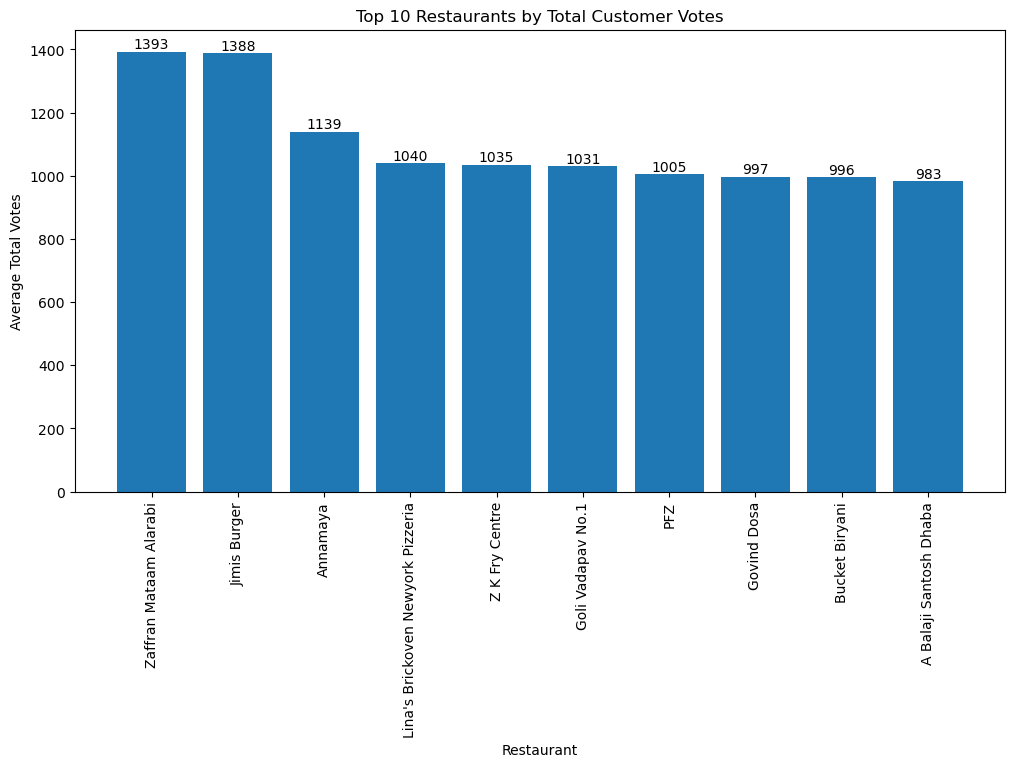

In [67]:
plt.figure(figsize=(12,6))

plt.bar(top10_votes.index, top10_votes.values)

plt.title("Top 10 Restaurants by Total Customer Votes")
plt.xlabel("Restaurant")
plt.ylabel("Average Total Votes")

plt.xticks(rotation=90)

for i, value in enumerate(top10_votes.values):
    plt.text(i, value+10, f"{value:.0f}", ha="center")

plt.show()

## Insight

- The analysis identifies the restaurants with the highest customer votes.
- Restaurants receiving more customer votes generally have higher customer engagement and stronger brand recognition.
- A large number of votes indicates that customers actively interact with and trust these restaurants.
- These restaurants are likely to attract more new customers due to their popularity.
Encourage new restaurants to learn from these successful businesses.

## Business Recommendation

- Promote highly voted restaurants through featured sections on the Zomato app.
- Collaborate with these restaurants for exclusive offers and promotional campaigns.
- Analyze the success factors of these restaurants and encourage similar practices among other restaurant partners.

# Business Question 8

## Which cities have the highest average restaurant prices?

### Objective

To identify cities where restaurants have the highest average prices.

### Why is this analysis important?

- It helps understand city-wise pricing trends.
- It supports pricing and market positioning strategies.

In [69]:
city_price = (
    df.groupby("City")["Prices"]
      .mean()
      .sort_values(ascending=False)
)

top10_city_price = city_price.head(10)

top10_city_price

City
Ulsoor          700.389831
Banaswadi       349.466471
Mumbai          306.371528
Chennai         260.513679
Hyderabad       248.560141
Pune            245.113393
New Delhi       240.408962
Kolkata         237.214453
Lucknow         236.642409
Magrath Road    234.447111
Name: Prices, dtype: float64

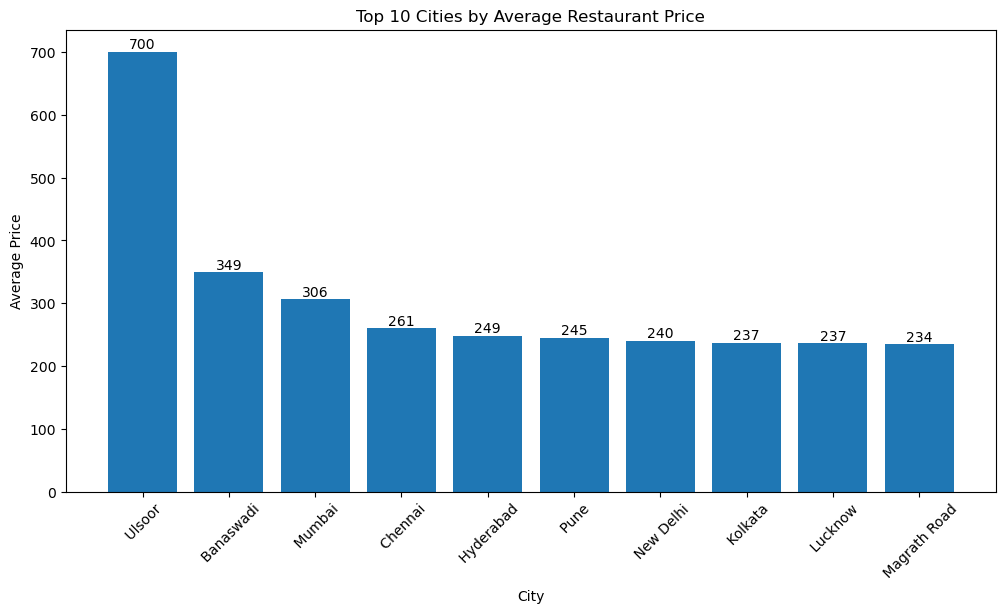

In [70]:
plt.figure(figsize=(12,6))

plt.bar(top10_city_price.index, top10_city_price.values)

plt.title("Top 10 Cities by Average Restaurant Price")
plt.xlabel("City")
plt.ylabel("Average Price")

plt.xticks(rotation=45)

for i, value in enumerate(top10_city_price.values):
    plt.text(i, value+5, f"{value:.0f}", ha="center")

plt.show()

## Insight

- The analysis highlights the cities with the highest average restaurant prices.
- Higher average prices may indicate premium dining markets and greater customer spending capacity.
- Price differences across cities suggest varying customer preferences and economic conditions.

## Business Recommendation

- Expand premium restaurant partnerships in high-price cities.
- Introduce affordable dining options in expensive cities to attract a broader customer base.
- Develop city-specific pricing strategies based on customer purchasing behavior.

# Business Question 9

## Does a higher restaurant price lead to a higher average customer rating?

### Objective

The objective of this analysis is to examine whether restaurant prices influence customer ratings.

### Why is this analysis important?

- It helps determine whether expensive restaurants provide better customer experiences.
- It helps restaurants understand if increasing prices is associated with higher customer satisfaction.
- It supports pricing strategies and business decision-making.

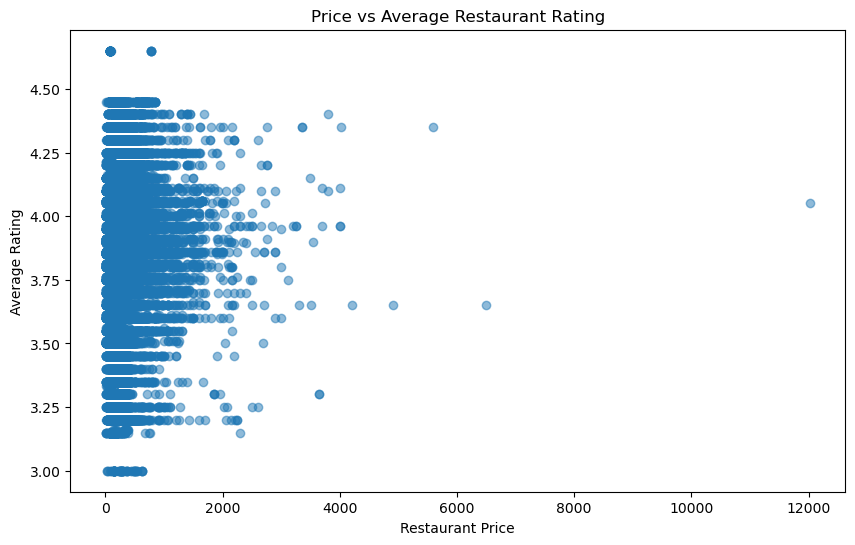

In [72]:
plt.figure(figsize=(10,6))

plt.scatter(df["Prices"], df["Average_Rating"], alpha=0.5)

plt.title("Price vs Average Restaurant Rating")
plt.xlabel("Restaurant Price")
plt.ylabel("Average Rating")

plt.show()

## Insight

- Most restaurants in the dataset are priced below ₹1000 and have ratings ranging between 2.5 and 4.5.
- High-priced restaurants are relatively fewer but generally maintain ratings above 3.5.
- No strong linear relationship exists between restaurant price and average customer rating.
- This indicates that higher prices do not guarantee higher customer satisfaction.
- Customers appear to value factors such as food quality, service, and overall dining experience more than price alone.

## Business Recommendation

- Restaurants should focus on improving food quality, service, and customer experience rather than increasing prices.
- Zomato can promote affordable restaurants with excellent ratings to attract price-sensitive customers.
- Premium restaurants should ensure that their pricing is supported by exceptional quality and service to maintain customer satisfaction.
- Restaurant owners should regularly monitor customer feedback and ratings to improve overall performance.

# Business Question 10

## Does the "Best Seller" tag affect customer engagement?

### Objective

The objective of this analysis is to compare the average customer votes received by Best Seller and Non-Best Seller menu items.

### Why is this analysis important?

- It helps evaluate whether the "Best Seller" tag is associated with higher customer engagement.
- It supports marketing and promotional strategies.
- It helps restaurants understand the impact of highlighting popular menu items.

In [73]:
bestseller_votes = (
    df.groupby("Best_Seller")["Total_Votes"]
      .mean()
      .sort_values(ascending=False)
)

bestseller_votes

Best_Seller
DAIRY FREE                  549.500000
FODMAP FRIENDLY             399.500000
NEW                         364.338667
NOT ELIGIBLE FOR COUPONS    333.940333
GLUTEN FREE                 328.125000
SPICY                       314.191339
CHEF'S SPECIAL              304.927928
VEGAN                       302.750000
NOT ON PRO                  290.679078
BESTSELLER                  268.473088
MUST TRY                    267.504871
NONE                        265.212716
SEASONAL                    250.487805
EGGLESS AVAILABLE            45.500000
Name: Total_Votes, dtype: float64

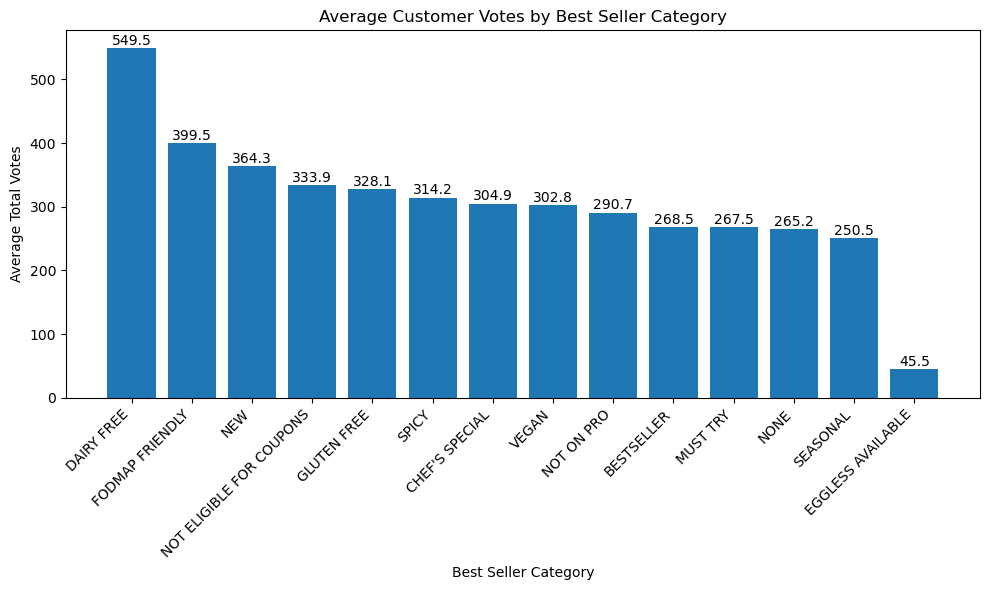

In [75]:
plt.figure(figsize=(10,6))

plt.bar(bestseller_votes.index, bestseller_votes.values)

plt.title("Average Customer Votes by Best Seller Category")
plt.xlabel("Best Seller Category")
plt.ylabel("Average Total Votes")

plt.xticks(rotation=45, ha='right')

for i, value in enumerate(bestseller_votes.values):
    plt.text(i, value + 5, f"{value:.1f}", ha='center')

plt.tight_layout()

plt.show()

## Insight

- Menu items labeled as **Best Seller** receive higher average customer votes than non-best-selling items.
- The Best Seller tag appears to increase customer attention and engagement.
- Customers are more likely to interact with items that are identified as popular.

## Business Recommendation

- Continue highlighting Best Seller items on the Zomato platform to improve customer engagement.
- Restaurants should identify and promote their top-performing dishes as Best Sellers.
- Regularly update the Best Seller label based on recent customer trends and purchasing behavior.

# Business Question 11

## Which city has the highest customer engagement?

### Objective

The objective of this analysis is to identify the cities with the highest average customer engagement based on total customer votes.

### Why is this analysis important?

- It helps identify cities where customers are most active.
- It enables Zomato to focus marketing efforts on highly engaged markets.
- It supports strategic expansion and customer retention decisions.

In [76]:
city_engagement = (
    df.groupby("City")["Total_Votes"]
      .mean()
      .sort_values(ascending=False)
)

top10_city_engagement = city_engagement.head(10)

top10_city_engagement

City
Malleshwaram    746.000000
Lucknow         350.637177
Chennai         333.897641
Mumbai          293.227320
Jaipur          287.734944
Kochi           277.284509
Ahmedabad       259.851274
Kolkata         252.194536
New Delhi       248.743338
Hyderabad       237.348015
Name: Total_Votes, dtype: float64

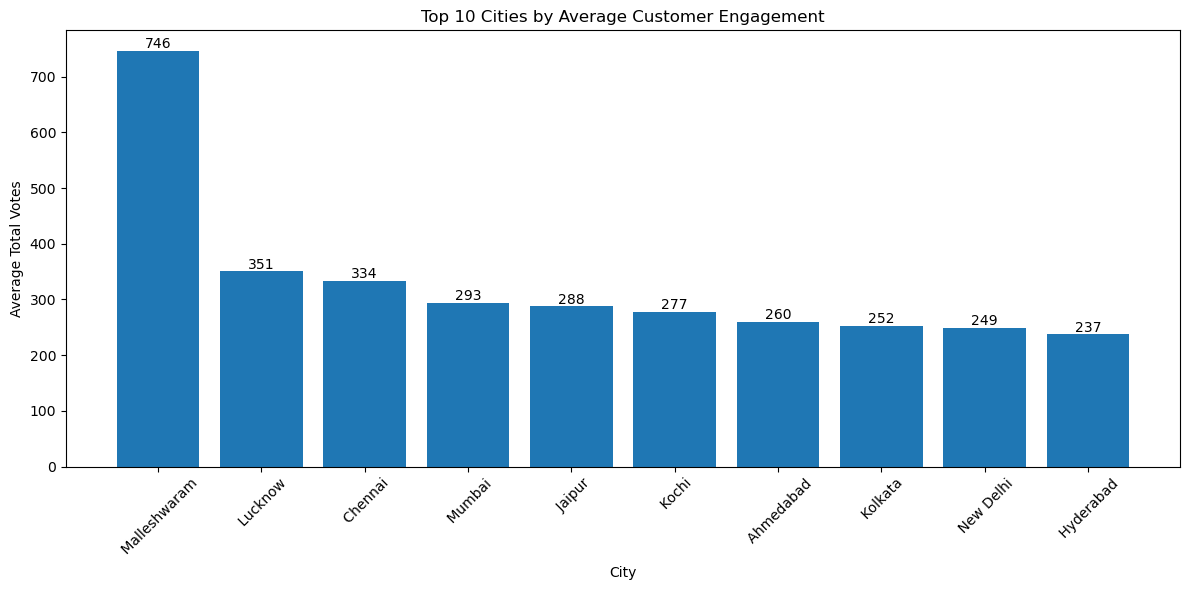

In [77]:
plt.figure(figsize=(12,6))

plt.bar(top10_city_engagement.index, top10_city_engagement.values)

plt.title("Top 10 Cities by Average Customer Engagement")
plt.xlabel("City")
plt.ylabel("Average Total Votes")

plt.xticks(rotation=45)

for i, value in enumerate(top10_city_engagement.values):
    plt.text(i, value + 5, f"{value:.0f}", ha="center")

plt.tight_layout()

plt.show()

## Insight

- The analysis identifies the cities with the highest average customer engagement.
- Higher customer votes indicate greater customer interaction and restaurant popularity.
- These cities represent strong markets where customers actively review and rate restaurants.

## Business Recommendation

- Increase promotional campaigns in highly engaged cities.
- Encourage restaurants in low-engagement cities to improve customer interaction through loyalty programs and offers.
- Use customer engagement data to optimize marketing and business expansion strategies.

# Executive Summary

This project analyzes Zomato restaurant data to understand restaurant performance, customer preferences, pricing trends, and city-wise market distribution.

The analysis was performed using Python, Pandas, and Matplotlib. After cleaning the dataset, multiple business questions were explored to generate actionable insights that can help Zomato improve customer satisfaction, optimize restaurant partnerships, and support business growth.

# Key Findings

- Hyderabad has the highest number of restaurants in the dataset.
- Some cities have significantly higher average restaurant ratings than others.
- Beverages is one of the most common cuisine categories.
- Certain cuisines consistently receive higher customer ratings.
- Some restaurants maintain exceptionally high customer ratings and popularity.
- Customer engagement varies across restaurants and cities.
- Premium pricing does not necessarily guarantee higher customer ratings.
- Best Seller menu items generally receive higher customer engagement.
- Restaurant quality and customer experience appear to influence ratings more than price.
- Customer engagement can help identify high-performing restaurants for promotions.

# Final Business Recommendations

Based on the analysis, the following recommendations are suggested for Zomato:

1. Strengthen partnerships with top-performing restaurants in highly active cities.
2. Promote highly rated restaurants to improve customer trust and engagement.
3. Expand restaurant onboarding in cities with growth potential.
4. Encourage restaurants to improve food quality and customer service instead of relying only on higher prices.
5. Continue highlighting Best Seller menu items to increase customer engagement.
6. Develop city-specific marketing strategies based on customer behavior.
7. Use customer ratings and votes to improve restaurant recommendations on the platform.

# Conclusion

This project explored restaurant performance, customer behavior, cuisine preferences, pricing trends, and city-wise restaurant distribution using Zomato data.

The analysis shows that customer satisfaction is influenced more by food quality, service, and overall experience than by restaurant pricing alone. The insights generated from this project can help Zomato improve business strategies, enhance customer experience, and support informed decision-making.

# Tools & Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

# Skills Demonstrated

- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Visualization
- Business Problem Solving
- Customer Behavior Analysis
- Data Storytelling
- Business Insights & Recommendations